<a href="https://colab.research.google.com/github/JacekDrzycimski/6tunnel/blob/master/2D_line_OSM_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import folium

# Create a map centered around a sample coordinate area
# (Using sample coordinates, e.g., near a typical survey location or center of the US)
map_center = [35.0, -95.0]
m = folium.Map(location=map_center, zoom_start=12, tiles='OpenStreetMap')

# Sample data: Shots (Sources) and Receivers
# In practice, you would load these from your dataset (e.g., a pandas DataFrame)
shots = [
    {"id": "Shot 1", "lat": 35.01, "lon": -95.02},
    {"id": "Shot 2", "lat": 35.02, "lon": -95.01},
]

receivers = [
    {"id": "Rec 1", "lat": 34.99, "lon": -95.03},
    {"id": "Rec 2", "lat": 34.98, "lon": -95.02},
    {"id": "Rec 3", "lat": 34.97, "lon": -95.01},
]

# Plot Shots as Red Markers
for shot in shots:
    folium.Marker(
        location=[shot["lat"], shot["lon"]],
        popup=shot["id"],
        icon=folium.Icon(color="red", icon="star")
    ).add_to(m)

# Plot Receivers as Blue Markers
for rec in receivers:
    folium.Marker(
        location=[rec["lat"], rec["lon"]],
        popup=rec["id"],
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(m)

# Display the map
m

In [ ]:
import folium
from branca.element import Template, MacroElement

# Combine points in order to represent the 2D seismic survey line
survey_points = []

# We will draw a line starting from the shots down through the receivers
for shot in shots:
    survey_points.append([shot["lat"], shot["lon"]])
for rec in receivers:
    survey_points.append([rec["lat"], rec["lon"]])

# Draw the survey line
folium.PolyLine(
    locations=survey_points,
    color="purple",
    weight=3.5,
    opacity=0.85,
    tooltip="2D Survey Line Path"
).add_to(m)

# Create HTML for Legend
legend_html = '''
{% macro html(this, kwargs) %}
<div style="
    position: fixed;
    bottom: 50px;
    left: 50px;
    width: 150px;
    height: 110px;
    border: 2px solid grey;
    z-index:9999;
    font-size:14px;
    background-color: white;
    opacity: 0.85;
    padding: 10px;
    border-radius: 5px;
    font-family: Arial, sans-serif;
">
    <h4 style="margin-top: 0; margin-bottom: 8px; font-size: 14px;"><b>Legend</b></h4>
    <div style="margin-bottom: 5px;">
        <span style="display: inline-block; width: 12px; height: 12px; background-color: red; border-radius: 50%; margin-right: 5px;"></span>
        Shots (Sources)
    </div>
    <div style="margin-bottom: 5px;">
        <span style="display: inline-block; width: 12px; height: 12px; background-color: blue; border-radius: 50%; margin-right: 5px;"></span>
        Receivers
    </div>
    <div>
        <span style="display: inline-block; width: 20px; height: 3px; background-color: purple; margin-right: 5px; vertical-align: middle;"></span>
        Survey Line
    </div>
</div>
{% endmacro %}
'''

template = Template(legend_html)
macro = MacroElement()
macro._template = template
m.get_root().add_child(macro)

# Re-display the updated map
m

In [1]:
!pip install pyproj

In [2]:
import folium
from pyproj import Transformer

# Define your UTM Zone projection EPSG code.
# For example, UTM Zone 15N (commonly used in central US) is EPSG:32615
# Replace 32615 with the EPSG code matching your survey's coordinate system.
utm_epsg = "epsg:32615"
wgs84_epsg = "epsg:4326"

# Create a transformer from Easting/Northing (UTM) to Lat/Lon (WGS84)
# always_xy=True ensures input order is (Easting, Northing) and output is (Lon, Lat)
transformer = Transformer.from_crs(utm_epsg, wgs84_epsg, always_xy=True)

# Sample Easting/Northing survey points (e.g., in UTM Zone 15N)
sample_utm_points = [
    {"id": "Point A", "easting": 317000, "northing": 3875000},
    {"id": "Point B", "easting": 318000, "northing": 3876000},
    {"id": "Point C", "easting": 319000, "northing": 3877000}
]

# Convert coordinates and store them
qc_points = []
for pt in sample_utm_points:
    lon, lat = transformer.transform(pt["easting"], pt["northing"])
    qc_points.append({
        "id": pt["id"],
        "easting": pt["easting"],
        "northing": pt["northing"],
        "lat": lat,
        "lon": lon
    })

# Print converted values to QC check them visually
for pt in qc_points:
    print(f"{pt['id']} -> Easting/Northing: ({pt['easting']}, {pt['northing']}) | Lat/Lon: ({pt['lat']:.6f}, {pt['lon']:.6f})")

Point A -> Easting/Northing: (317000, 3875000) | Lat/Lon: (35.001078, -95.005328)
Point B -> Easting/Northing: (318000, 3876000) | Lat/Lon: (35.010271, -94.994595)
Point C -> Easting/Northing: (319000, 3877000) | Lat/Lon: (35.019462, -94.983859)


In [3]:
# Initialize Map at the center of our QC points
center_lat = sum(p["lat"] for p in qc_points) / len(qc_points)
center_lon = sum(p["lon"] for p in qc_points) / len(qc_points)

m_qc = folium.Map(location=[center_lat, center_lon], zoom_start=14, tiles='OpenStreetMap')

# MapConverted Points to visually check their positions against local geography
for pt in qc_points:
    folium.Marker(
        location=[pt["lat"], pt["lon"]],
        popup=f"<b>{pt['id']}</b><br>E: {pt['easting']}<br>N: {pt['northing']}",
        icon=folium.Icon(color="green", icon="ok-sign")
    ).add_to(m_qc)

m_qc

In [4]:
import pandas as pd
from pyproj import Transformer

def convert_coords_list(coords, utm_zone="epsg:32615"):
    """
    Converts a list of dicts containing Easting and Northing to WGS84 Lat/Lon.

    Parameters:
      coords (list of dicts): list containing {'id': ..., 'easting': ..., 'northing': ...}
      utm_zone (str): EPSG code of the input system
    """
    transformer = Transformer.from_crs(utm_zone, "epsg:4326", always_xy=True)

    converted_list = []
    for pt in coords:
        lon, lat = transformer.transform(pt["easting"], pt["northing"])
        converted_list.append({
            "Point ID": pt["id"],
            "Easting": pt["easting"],
            "Northing": pt["northing"],
            "Latitude": lat,
            "Longitude": lon
        })

    return pd.DataFrame(converted_list)

# Example list of coordinates to convert
coordinate_list = [
    {"id": "WP-01", "easting": 317150, "northing": 3875120},
    {"id": "WP-02", "easting": 317520, "northing": 3875480},
    {"id": "WP-03", "easting": 318110, "northing": 3875850},
    {"id": "WP-04", "easting": 318950, "northing": 3876300}
]

# Convert and display
df_converted = convert_coords_list(coordinate_list, utm_zone="epsg:32615")
display(df_converted)

,Point ID,Easting,Northing,Latitude,Longitude
0,WP-01,317150,3875120,35.002187,-95.003712
1,WP-02,317520,3875480,35.005498,-94.999738
2,WP-03,318110,3875850,35.008939,-94.993357
3,WP-04,318950,3876300,35.013145,-94.984254


In [5]:
import folium

# Calculate the center of the converted coordinates to set the initial map view
mean_lat = df_converted['Latitude'].mean()
mean_lon = df_converted['Longitude'].mean()

# Initialize a folium map centered on the converted points
m_converted = folium.Map(location=[mean_lat, mean_lon], zoom_start=14, tiles='OpenStreetMap')

# Add a marker for each point in the DataFrame
for _, row in df_converted.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"<b>{row['Point ID']}</b><br>Easting: {row['Easting']}<br>Northing: {row['Northing']}",
        icon=folium.Icon(color="blue", icon="info-sign")
    ).add_to(m_converted)

# Display the map
m_converted

In [6]:
# Extract Latitude and Longitude coordinate pairs in order as a list of lists
line_path = df_converted[['Latitude', 'Longitude']].values.tolist()

# Draw a purple PolyLine to connect the points sequentially
folium.PolyLine(
    locations=line_path,
    color="purple",
    weight=3,
    opacity=0.8,
    tooltip="Connected Survey Path"
).add_to(m_converted)

# Re-display the updated map
m_converted

In [7]:
# Export the converted coordinates DataFrame to a CSV file
csv_filename = "converted_coordinates.csv"
df_converted.to_csv(csv_filename, index=False)

print(f"Success! Your converted coordinates have been saved to '{csv_filename}'.")

Success! Your converted coordinates have been saved to 'converted_coordinates.csv'.


In [8]:
display(df_converted.head(5))

,Point ID,Easting,Northing,Latitude,Longitude
0,WP-01,317150,3875120,35.002187,-95.003712
1,WP-02,317520,3875480,35.005498,-94.999738
2,WP-03,318110,3875850,35.008939,-94.993357
3,WP-04,318950,3876300,35.013145,-94.984254


In [9]:
# Calculate summary statistics for the numeric coordinate columns
stats_df = df_converted[['Easting', 'Northing', 'Latitude', 'Longitude']].describe()
display(stats_df)

,Easting,Northing,Latitude,Longitude
count,4.000000,4.000000e+00,4.000000,4.000000
mean,317932.500000,3.875688e+06,35.007442,-94.995265
std,785.127378,5.055278e+02,0.004696,0.008490
min,317150.000000,3.875120e+06,35.002187,-95.003712
25%,317427.500000,3.875390e+06,35.004670,-95.000732
50%,317815.000000,3.875665e+06,35.007218,-94.996548
75%,318320.000000,3.875962e+06,35.009990,-94.991081
max,318950.000000,3.876300e+06,35.013145,-94.984254


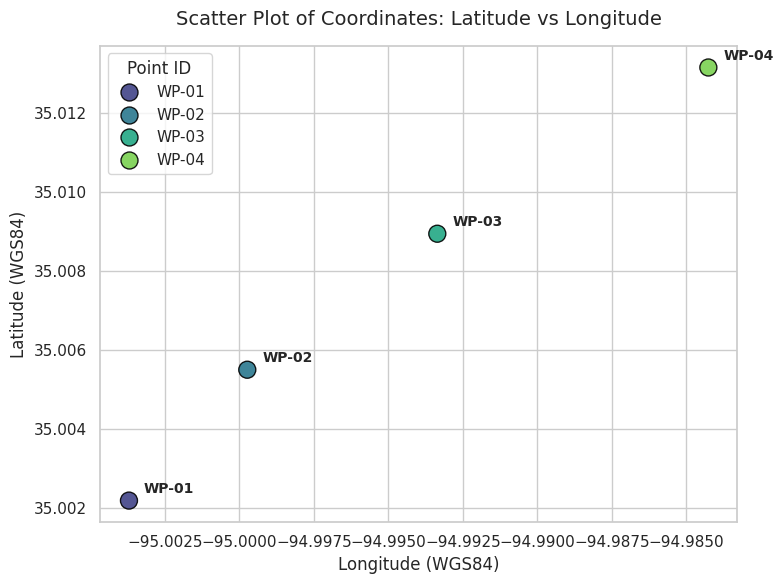

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plotting style
sns.set_theme(style="whitegrid")

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_converted,
    x="Longitude",
    y="Latitude",
    hue="Point ID",
    s=150,
    palette="viridis",
    edgecolor="black",
    alpha=0.9
)

# Annotate the points on the plot
for _, row in df_converted.iterrows():
    plt.text(
        row["Longitude"] + 0.0005,
        row["Latitude"] + 0.0002,
        row["Point ID"],
        fontsize=10,
        weight='bold'
    )

plt.title("Scatter Plot of Coordinates: Latitude vs Longitude", fontsize=14, pad=15)
plt.xlabel("Longitude (WGS84)", fontsize=12)
plt.ylabel("Latitude (WGS84)", fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
from geopy.distance import geodesic
import pandas as pd

# Initialize lists to store step-by-step distances
segment_distances = []
cumulative_distance = 0.0
cumulative_distances = [0.0]

# Loop through the dataframe to compute distances between consecutive points
for i in range(len(df_converted) - 1):
    point_a = (df_converted.loc[i, 'Latitude'], df_converted.loc[i, 'Longitude'])
    point_b = (df_converted.loc[i+1, 'Latitude'], df_converted.loc[i+1, 'Longitude'])

    # Calculate distance in meters using geodesic
    dist_m = geodesic(point_a, point_b).meters
    segment_distances.append(dist_m)

    cumulative_distance += dist_m
    cumulative_distances.append(cumulative_distance)

# Since segment_distances has 1 less element, pad with NaN for the first point's incoming distance
segment_distances_col = [float('nan')] + segment_distances

# Add calculations back to a copy of the dataframe for display
df_distances = df_converted.copy()
df_distances['Distance to Next (m)'] = pd.Series(segment_distances + [float('nan')])
df_distances['Cumulative Distance (m)'] = cumulative_distances

# Display the results
display(df_distances)

print("\n--- Path Summary ---")
for i in range(len(segment_distances)):
    pt_from = df_converted.loc[i, 'Point ID']
    pt_to = df_converted.loc[i+1, 'Point ID']
    print(f"Distance from {pt_from} to {pt_to}: {segment_distances[i]:.2f} meters")
print(f"Total Survey Path Distance: {cumulative_distance:.2f} meters")

,Point ID,Easting,Northing,Latitude,Longitude,Distance to Next (m),Cumulative Distance (m)
0,WP-01,317150,3875120,35.002187,-95.003712,516.230577,0.000000
1,WP-02,317520,3875480,35.005498,-94.999738,696.413088,516.230577
2,WP-03,318110,3875850,35.008939,-94.993357,952.937209,1212.643665
3,WP-04,318950,3876300,35.013145,-94.984254,NaN,2165.580874



--- Path Summary ---
Distance from WP-01 to WP-02: 516.23 meters
Distance from WP-02 to WP-03: 696.41 meters
Distance from WP-03 to WP-04: 952.94 meters
Total Survey Path Distance: 2165.58 meters


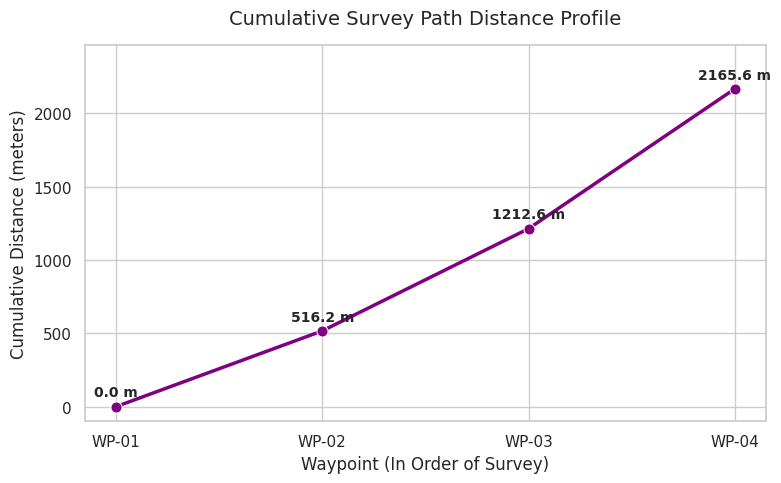

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plotting style
sns.set_theme(style="whitegrid")

# Create the cumulative distance line chart
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_distances,
    x="Point ID",
    y="Cumulative Distance (m)",
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="purple"
)

# Annotate the values above each point
for idx, row in df_distances.iterrows():
    plt.text(
        row["Point ID"],
        row["Cumulative Distance (m)"] + 50,
        f"{row['Cumulative Distance (m)']:.1f} m",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Cumulative Survey Path Distance Profile", fontsize=14, pad=15)
plt.xlabel("Waypoint (In Order of Survey)", fontsize=12)
plt.ylabel("Cumulative Distance (meters)", fontsize=12)
plt.ylim(-100, df_distances["Cumulative Distance (m)"].max() + 300)
plt.tight_layout()
plt.show()

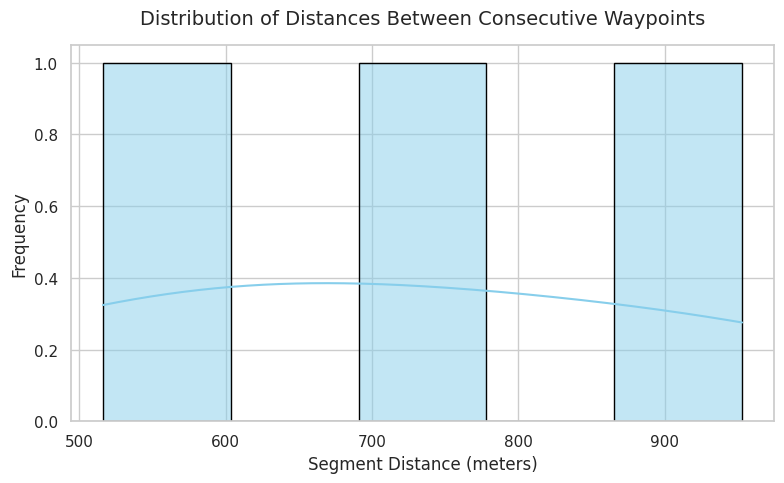

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plotting style
sns.set_theme(style="whitegrid")

# Extract valid individual segment distances (exclude NaN)
individual_distances = df_distances["Distance to Next (m)"].dropna()

# Create the histogram
plt.figure(figsize=(8, 5))
sns.histplot(
    individual_distances,
    bins=5,
    color="skyblue",
    edgecolor="black",
    kde=True
)

plt.title("Distribution of Distances Between Consecutive Waypoints", fontsize=14, pad=15)
plt.xlabel("Segment Distance (meters)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()

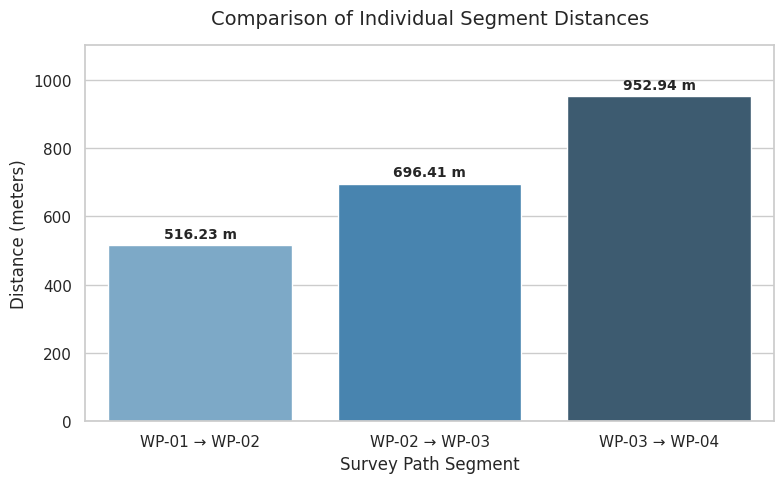

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create explicit labels for each segment
segments = []
for i in range(len(df_converted) - 1):
    pt_from = df_converted.loc[i, 'Point ID']
    pt_to = df_converted.loc[i+1, 'Point ID']
    segments.append(f"{pt_from} \u2192 {pt_to}")

# Set the plotting style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=segments,
    y=segment_distances,
    palette="Blues_d",
    hue=segments,
    legend=False
)

# Add the distance values on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f m", padding=3, fontsize=10, weight='bold')

plt.title("Comparison of Individual Segment Distances", fontsize=14, pad=15)
plt.xlabel("Survey Path Segment", fontsize=12)
plt.ylabel("Distance (meters)", fontsize=12)
plt.ylim(0, max(segment_distances) + 150)

plt.tight_layout()
plt.show()

In [15]:
# Calculate the average segment distance
average_segment_distance = sum(segment_distances) / len(segment_distances)
print(f"Average Segment Distance: {average_segment_distance:.2f} meters")

Average Segment Distance: 721.86 meters
